In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
from multiprocessing import Pool
from catboost import CatBoostRegressor
from hyperopt import hp, tpe, Trials, STATUS_OK, fmin
from hyperopt.early_stop import no_progress_loss
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")
from flaml import AutoML
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import shap
from tqdm import tqdm
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, 
    AdaBoostRegressor, BaggingRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Lasso, LassoLars, LinearRegression, Ridge,
    SGDRegressor, PassiveAggressiveRegressor, ElasticNet, HuberRegressor,
    BayesianRidge, OrthogonalMatchingPursuit
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import NuSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import ast
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
train=pd.read_csv('/home/ychen3338/project_2/data/tox_train.csv')
test=pd.read_csv('/home/ychen3338/project_2/data/tox_test.csv')

In [3]:
class morgan_fp:
    def __init__(self, radius, length):
        self.radius = radius
        self.length = length
    def __call__(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, self.length)
        npfp = np.array(list(fp.ToBitString())).astype('float32')
        return npfp

In [4]:
def conv_data(data, fp):
    data['c-fp'] = data['Cation'].apply(fp)
    x_c=np.array(list(data['c-fp']))
    data['a-fp'] = data['Anion'].apply(fp)
    x_a=np.array(list(data['a-fp']))
    xx = np.concatenate([x_c, x_a], axis =1)
    y = data['logEC50'].values
    return xx, y

In [5]:
# result = pd.read_csv('/home/ychen3338/project_2/code/tox/tox_MF.csv')
# result.sort_values('loss', ascending=True, inplace=True)
# result.reset_index(drop=True, inplace=True)

In [6]:
# result.head()

In [7]:
# params = result.loc[0, 'params']
# params = ast.literal_eval(params)

In [8]:
# params

{'bagging_temperature': 164.9929320084992, 'depth': 5, 'fp_length': 1097, 'fp_radius': 2, 'iterations': 954, 'l2_leaf_reg': 3.0688155491904245, 'learning_rate': 0.024819698205080988, 'random_strength': 74.8366958504647}

In [5]:
params ={'bagging_temperature': 164.9929320084992, 'depth': 5,
          'fp_length': 1097, 'fp_radius': 2,
            'iterations': 954, 'l2_leaf_reg': 3.0688155491904245, 
            'learning_rate': 0.024819698205080988, 
            'random_strength': 74.8366958504647}

In [6]:
models = [
    ('CatBoost', CatBoostRegressor(depth = params['depth'], l2_leaf_reg= params['l2_leaf_reg'], learning_rate = params['learning_rate'],
                         iterations=params['iterations'], bagging_temperature=params['bagging_temperature'],
                         random_strength=params['random_strength'],random_state=10, verbose=False)),
    ('XGBoost', XGBRegressor(random_state=10)),
    ('LightGBM', LGBMRegressor(random_state=10)),
    ('RandomForest', RandomForestRegressor(random_state=10)),
    ('ExtraTrees', ExtraTreesRegressor(random_state=10)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=10)),
    ('HistGradientBoosting', HistGradientBoostingRegressor(random_state=10)),
    ('DecisionTree', DecisionTreeRegressor(random_state=10)),

    ('SVM', make_pipeline(StandardScaler(), SVR())),
    ('NuSVM', make_pipeline(StandardScaler(), NuSVR())),
    ('MLP', make_pipeline(StandardScaler(), MLPRegressor(max_iter=1000, random_state=10))),
    
    ('Lasso', make_pipeline(StandardScaler(), Lasso(random_state=10))),
    ('Ridge', make_pipeline(StandardScaler(), Ridge(random_state=10))),
    ('ElasticNet', make_pipeline(StandardScaler(), ElasticNet(random_state=10))),
    ('LassoLars', LassoLars()),
    ('LinearRegression', LinearRegression()),
    ('SGDRegressor', SGDRegressor(random_state=10)),
    ('BayesianRidge', BayesianRidge()),
    ('OrthogonalMatching', OrthogonalMatchingPursuit()),

    ('AdaBoost', AdaBoostRegressor(random_state=10)),
    ('Bagging', BaggingRegressor(random_state=10)),

    ('HuberRegressor', HuberRegressor()),
    ('PassiveAggressive', PassiveAggressiveRegressor(random_state=10)),
    ('KNN', KNeighborsRegressor())
]
fp = morgan_fp(params['fp_radius'], params['fp_length'])
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)

results = []

for name, model in models:
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)
        results.append((name, score))
    except Exception as e:
        print(f"{name} Error: {str(e)}")

sorted_results = sorted(results, key=lambda x: x[1], reverse=True)

print("Algorithm R² Ranking:")
for idx, (name, score) in enumerate(sorted_results, 1):
    print(f"{idx}. {name}: {score:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 234
[LightGBM] [Info] Number of data points in the train set: 338, number of used features: 117
[LightGBM] [Info] Start training from score 2.662533
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [7]:
fp = morgan_fp(params['fp_radius'], params['fp_length'])

automl = AutoML(random_state=42)
n_jobs = 16
time_budget = 1500 # in seconds


In [8]:
automl_settings = {
    "time_budget": time_budget,
    "metric": 'mse',
    "task": 'regression',
    "eval_method": "cv",
    "n_splits": 5,
    "estimator_list": [
        'xgboost', 
        'xgb_limitdepth', 
        'rf', 
        # 'lrl1', 
        'catboost', 
        'extra_tree', 
        'histgb',
        'kneighbor', 
        'sgd', 
        'enet', 
        'lassolars', 
        'lgbm',
    ],
    "n_jobs": n_jobs,  
    "log_file_name": '/home/ychen3338/project_2/code/tox/AutoML_emulator.log',  

}

X, y = conv_data(train, fp)
automl.fit(X_train=X, y_train=y, **automl_settings)
print("Best estimator:", automl.model.estimator)

[flaml.automl.logger: 07-14 21:47:33] {1728} INFO - task = regression
[flaml.automl.logger: 07-14 21:47:33] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 07-14 21:47:33] {1838} INFO - Minimizing error metric: mse
[flaml.automl.logger: 07-14 21:47:33] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'catboost', 'extra_tree', 'histgb', 'kneighbor', 'sgd', 'enet', 'lassolars', 'lgbm']
[flaml.automl.logger: 07-14 21:47:33] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-14 21:47:33] {2393} INFO - Estimated sufficient time budget=3631s. Estimated necessary time budget=27s.
[flaml.automl.logger: 07-14 21:47:33] {2442} INFO -  at 0.4s,	estimator xgboost's best error=0.8595,	best estimator xgboost's best error=0.8595
[flaml.automl.logger: 07-14 21:47:33] {2258} INFO - iteration 1, current learner histgb
[flaml.automl.logger: 07-14 21:47:33] {2442} INFO -  at 0.8s,	estimator histgb's best error=0.8546,	best estimator hi

Best estimator: LGBMRegressor(colsample_bytree=0.5566865982278889,
              learning_rate=0.11433051444641743, max_bin=127,
              min_child_samples=3, n_estimators=305, n_jobs=16, num_leaves=5,
              reg_alpha=0.002436258116322796, reg_lambda=9.769599177763295,
              verbose=-1)

In [9]:
best_model = automl.model.estimator
joblib.dump(best_model, 'best_lgbm_model.pkl')

['best_lgbm_model.pkl']

In [10]:
best_model = joblib.load('/home/ychen3338/project_2/code/tox/best_lgbm_model.pkl')

In [11]:
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)
best_model.fit(X_train, y_train)
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [12]:
print("Train R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_train, y_train_pred), mean_squared_error(y_train, y_train_pred)))
print("Test  R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_test, y_test_pred), mean_squared_error(y_test, y_test_pred)))

Train R2: 0.8493, MSE: 0.1748
Test  R2: 0.6626, MSE: 0.3737


In [ ]:
# chosen_model = CatBoostRegressor(depth = params['depth'], l2_leaf_reg= params['l2_leaf_reg'], learning_rate = params['learning_rate'],
#                          iterations=params['iterations'], bagging_temperature=params['bagging_temperature'],
#                          random_strength=params['random_strength'],random_state=10, verbose=False)

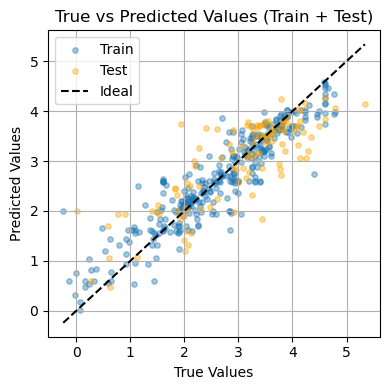

In [13]:
plt.figure(figsize=(4,4))

plt.scatter(y_train, y_train_pred, label='Train', alpha=0.4, s=15)
plt.scatter(y_test, y_test_pred, label='Test', alpha=0.4, s=15, color='orange')

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values (Train + Test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

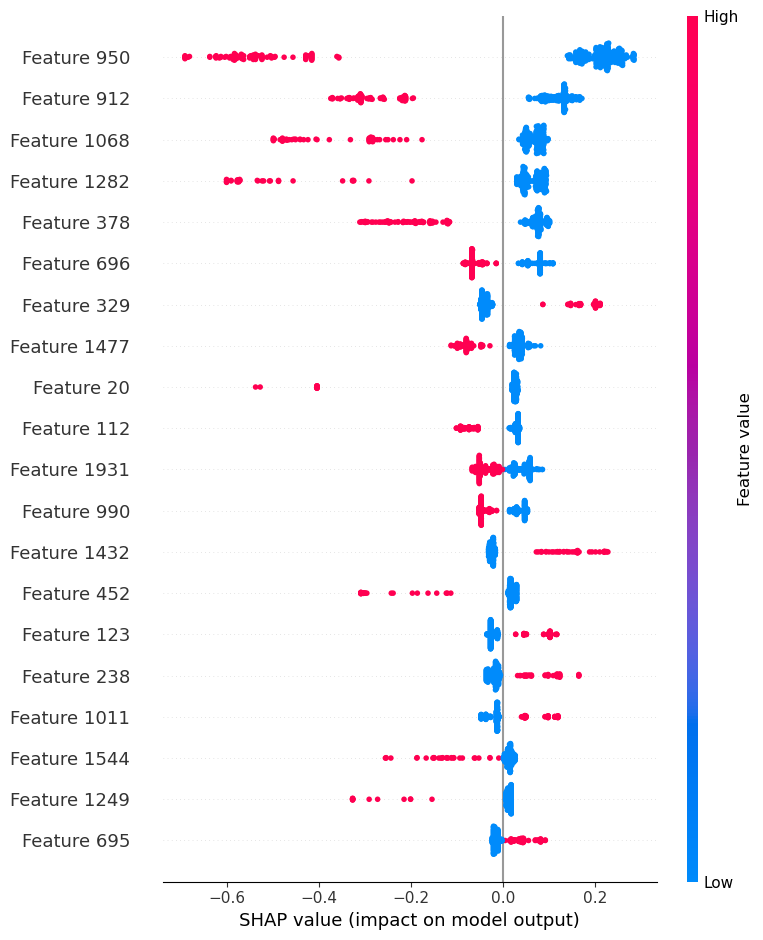

In [14]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train, max_display=20, color_bar=True,show=False)
plt.show()

In [16]:
# Convert SHAP values to a DataFrame
shap_values_df = pd.DataFrame(shap_values.values, columns=[f'Position_{i}' for i in range(X_train.shape[1])])

# Initialize a list to store mean SHAP values for positions where MF == 1
mean_shap_values = []

# Iterate over each position (feature) in the fingerprint
for i in range(X_train.shape[1]):
    # Filter SHAP values where the feature (fingerprint position) is set to 1
    shap_values_at_1 = shap_values_df[X_train[:, i] == 1][f'Position_{i}']

    # Calculate the mean SHAP value at this position when MF == 1
    mean_shap_value = shap_values_at_1.mean()
    mean_shap_values.append(mean_shap_value)

# Create a DataFrame to store the result
mean_shap_df = pd.DataFrame({
    'Position': range(len(mean_shap_values)),
    'Mean_SHAP_Value': mean_shap_values
})

print(mean_shap_df)

      Position  Mean_SHAP_Value
0            0              NaN
1            1              NaN
2            2              NaN
3            3        -0.067475
4            4              NaN
...        ...              ...
2189      2189              NaN
2190      2190              NaN
2191      2191              NaN
2192      2192              NaN
2193      2193              NaN

[2194 rows x 2 columns]


In [17]:
mean_shap_df.to_csv('/home/ychen3338/project_2/code/tox/shap_feature_tox.csv', index=False)

In [18]:
mean_shap_df= pd.read_csv('/home/ychen3338/project_2/code/tox/shap_feature_tox.csv')

In [ ]:
SHAP_PATH = '/home/ychen3338/project_2/code/tox/shap_feature_tox.csv'
TRAIN_PATH = '/home/ychen3338/project_2/data/tox_train.csv'

shap_df = pd.read_csv(SHAP_PATH)
shap_values = shap_df['Mean_SHAP_Value'].values
nonzero_bits = ((~np.isnan(shap_values)) & (shap_values != 0)).astype(int)
negative_bits = ((~np.isnan(shap_values)) & (shap_values > 0)).astype(int)
n_bits = len(nonzero_bits)

nonzero_fp = DataStructs.ExplicitBitVect(n_bits)
negative_fp = DataStructs.ExplicitBitVect(n_bits)
for i in range(n_bits):
    if nonzero_bits[i]:
        nonzero_fp.SetBit(i)
    if negative_bits[i]:
        negative_fp.SetBit(i)

train_df = pd.read_csv(TRAIN_PATH)
train_smiles = train_df['smile'].tolist()
train_tms = train_df['logEC50'].tolist()

In [20]:
dice_scores = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
        dice = DataStructs.DiceSimilarity(fp, nonzero_fp)
        dice_scores.append(dice)

p25_dice = np.percentile(dice_scores, 25)
print(f"Step 1: 25th percentile of Dice similarity = {p25_dice:.3f}")

Step 1: 25th percentile of Dice similarity = 0.116


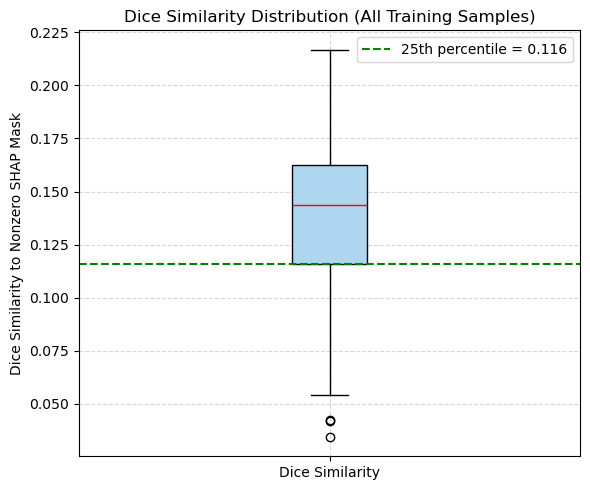

In [21]:
plt.figure(figsize=(6, 5))
plt.boxplot(dice_scores,
            labels=["Dice Similarity"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#AED6F1"),
            medianprops=dict(color="red"))

plt.axhline(y=p25_dice, color='green', linestyle='--', label=f"25th percentile = {p25_dice:.3f}")

plt.ylabel("Dice Similarity to Nonzero SHAP Mask")
plt.title("Dice Similarity Distribution (All Training Samples)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
tanimoto_scores_tm_low = []
for smi, logEC50 in zip(train_smiles, train_tms):
    if logEC50 <= 1:
        continue
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_tm_low.append(tanimoto)

tanimoto_scores_all = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_all.append(tanimoto)

pXX = np.percentile(tanimoto_scores_tm_low, 25)
print(f"Step 2: Tanimoto similarity of samples = {pXX:.3f}")


Step 2: Tanimoto similarity of samples = 0.040


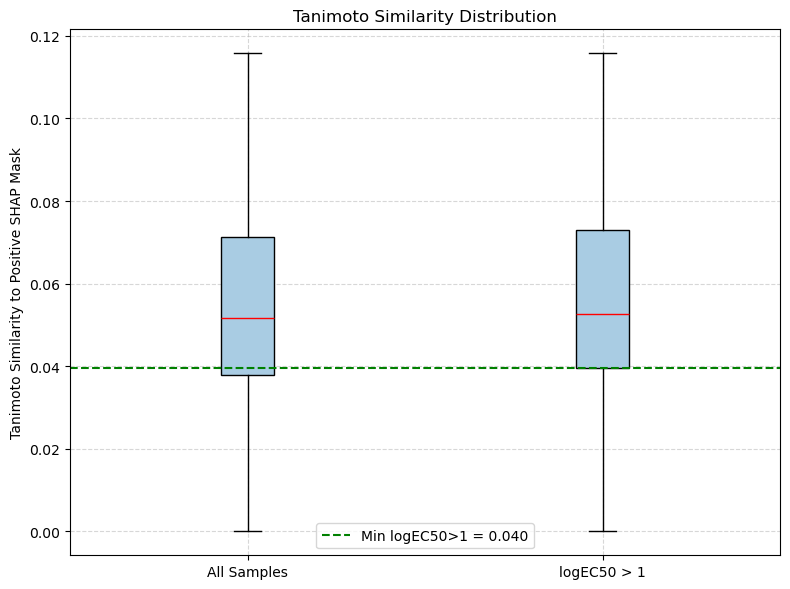

In [23]:
plt.figure(figsize=(8, 6))
plt.boxplot([tanimoto_scores_all, tanimoto_scores_tm_low],
            labels=["All Samples", "logEC50 > 1"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#A9CCE3"),
            medianprops=dict(color="red"))

plt.axhline(y=pXX, color='green', linestyle='--', label=f"Min logEC50>1 = {pXX:.3f}")
plt.ylabel("Tanimoto Similarity to Positive SHAP Mask")
plt.title("Tanimoto Similarity Distribution")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
df = pd.read_csv('/home/ychen3338/project_2/code/tox/simles_tox.csv')

In [25]:
len(df)

301458

In [28]:
df = df.drop_duplicates()
len(df)

301458

In [29]:
df = pd.read_csv('/home/ychen3338/project_2/data/after_m_tox.csv')

In [30]:
df = df.drop_duplicates()
len(df)

295529